# Social Media Impact on Teen Mental Health — Deep Analysis

This notebook analyzes **13 features** from `teen_mental_health.csv` to explore how social media use, sleep, academics, and psychosocial factors relate to **depression_label** (main target). Run all cells top-to-bottom for the full pipeline.

## Section 0 — Setup

Import libraries and load the dataset.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go  # noqa: F401
from scipy import stats
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier  # noqa: F401
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, f1_score, accuracy_score
)
from xgboost import XGBClassifier
import shap
from IPython.display import display

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)
RANDOM_STATE = 42

COLUMNS = [
    'age', 'gender', 'daily_social_media_hours', 'platform_usage', 'sleep_hours',
    'screen_time_before_sleep', 'academic_performance', 'physical_activity',
    'social_interaction_level', 'stress_level', 'anxiety_level', 'addiction_level',
    'depression_label'
]
NUMERIC_COLS = [
    'age', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep',
    'academic_performance', 'physical_activity', 'social_interaction_level',
    'stress_level', 'anxiety_level', 'addiction_level'
]
CAT_COLS = ['gender', 'platform_usage', 'social_interaction_level', 'depression_label']

def numeric_col(name):
  return 'social_interaction_level_encoded' if name == 'social_interaction_level' else name


In [2]:
df = pd.read_csv('data/teen_mental_health.csv')
df = df[COLUMNS].copy()

print('Shape:', df.shape)
print('\nDtypes:')
print(df.dtypes)
print('\nHead (5):')
display(df.head(5))
print('\nDescribe:')
display(df.describe(include='all'))

Shape: (1200, 13)

Dtypes:
age                           int64
gender                       object
daily_social_media_hours    float64
platform_usage               object
sleep_hours                 float64
screen_time_before_sleep    float64
academic_performance        float64
physical_activity           float64
social_interaction_level     object
stress_level                  int64
anxiety_level                 int64
addiction_level               int64
depression_label              int64
dtype: object

Head (5):


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0



Describe:


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200,1200.000000,1200,1200.000000,1200.000000,1200.000000,1200.000000,1200,1200.000000,1200.000000,1200.000000,1200.000000
unique,NaN,2,NaN,3,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN
top,NaN,male,NaN,Instagram,NaN,NaN,NaN,NaN,medium,NaN,NaN,NaN,NaN
freq,NaN,615,NaN,411,NaN,NaN,NaN,NaN,416,NaN,NaN,NaN,NaN
mean,15.928333,NaN,4.536667,NaN,6.449417,1.740333,2.990383,1.014500,NaN,5.445833,5.636667,5.565000,0.025833
std,2.021947,NaN,2.029599,NaN,1.442677,0.716660,0.576758,0.582185,NaN,2.903290,2.859453,2.830627,0.158704
min,13.000000,NaN,1.000000,NaN,4.000000,0.500000,2.000000,0.000000,NaN,1.000000,1.000000,1.000000,0.000000
25%,14.000000,NaN,2.800000,NaN,5.200000,1.100000,2.500000,0.500000,NaN,3.000000,3.000000,3.000000,0.000000
50%,16.000000,NaN,4.500000,NaN,6.500000,1.800000,2.990000,1.000000,NaN,5.000000,6.000000,6.000000,0.000000
75%,18.000000,NaN,6.300000,NaN,7.600000,2.400000,3.480000,1.500000,NaN,8.000000,8.000000,8.000000,0.000000


## Section 1 — Data Cleaning & Preprocessing

Check quality, remove duplicates, and encode categorical fields.

Missing values per column:
age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64


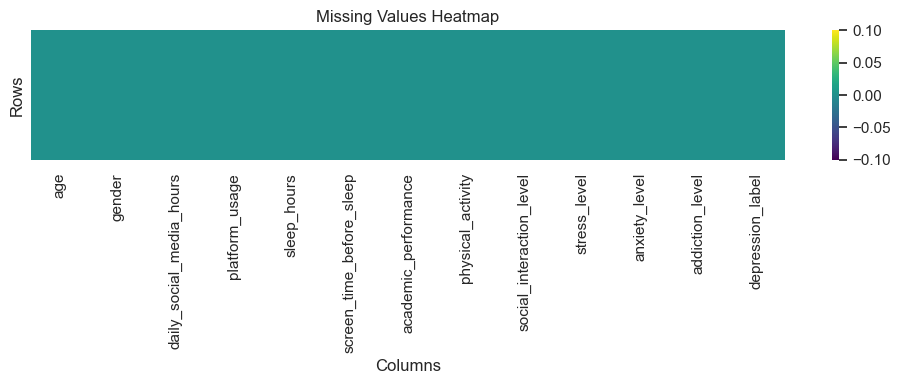

In [3]:
missing = df.isnull().sum()
print('Missing values per column:')
print(missing)

plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.tight_layout()
plt.show()

In [4]:
n_before = len(df)
df = df.drop_duplicates()
removed = n_before - len(df)
print(f'Duplicate rows removed: {removed}')

Duplicate rows removed: 0


In [5]:
for col in ['gender', 'platform_usage', 'depression_label']:
    print(f'\n{col} value_counts:')
    print(df[col].value_counts())


gender value_counts:
gender
male      615
female    585
Name: count, dtype: int64

platform_usage value_counts:
platform_usage
Instagram    411
TikTok       398
Both         391
Name: count, dtype: int64

depression_label value_counts:
depression_label
0    1169
1      31
Name: count, dtype: int64


In [6]:
# Map binary depression to readable labels, then encode target
dep_map = {0: 'No Depression', 1: 'Depression'}
if df['depression_label'].dtype != object:
    df['depression_label'] = df['depression_label'].map(dep_map)

le_dep = LabelEncoder()
df['depression_label_encoded'] = le_dep.fit_transform(df['depression_label'])
print('Depression encoding:', dict(zip(le_dep.classes_, le_dep.transform(le_dep.classes_))))

le_gender = LabelEncoder()
df['gender_encoded'] = le_gender.fit_transform(df['gender'])
le_platform = LabelEncoder()
df['platform_usage_encoded'] = le_platform.fit_transform(df['platform_usage'])
le_social = LabelEncoder()
df['social_interaction_level_encoded'] = le_social.fit_transform(df['social_interaction_level'])
print('Gender encoding:', dict(zip(le_gender.classes_, le_gender.transform(le_gender.classes_))))
print('Platform encoding:', dict(zip(le_platform.classes_, le_platform.transform(le_platform.classes_))))

Depression encoding: {'Depression': np.int64(0), 'No Depression': np.int64(1)}
Gender encoding: {'female': np.int64(0), 'male': np.int64(1)}
Platform encoding: {'Both': np.int64(0), 'Instagram': np.int64(1), 'TikTok': np.int64(2)}


## Section 2 — Exploratory Data Analysis (EDA)

Visualize distributions, categories, correlations, and group differences.

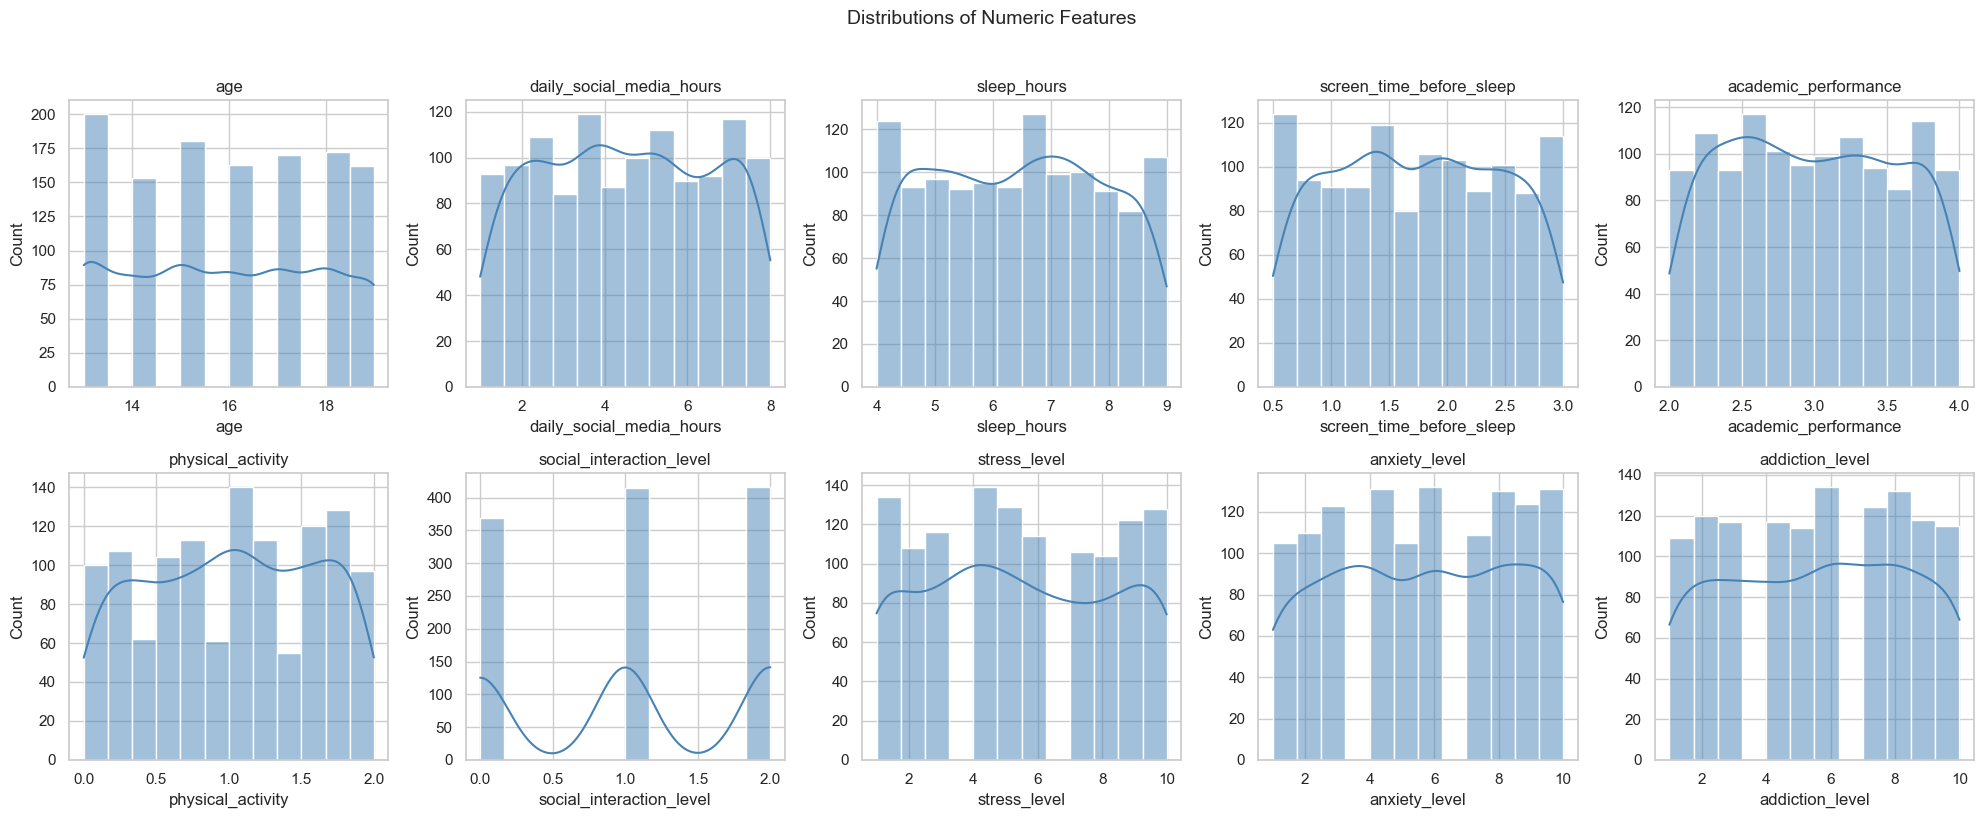

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.ravel()
plot_cols = NUMERIC_COLS + ['social_interaction_level']
plot_df = df.copy()
plot_df['social_interaction_level'] = plot_df['social_interaction_level_encoded']
for ax, col in zip(axes, plot_cols):
    sns.histplot(plot_df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
plt.suptitle('Distributions of Numeric Features', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

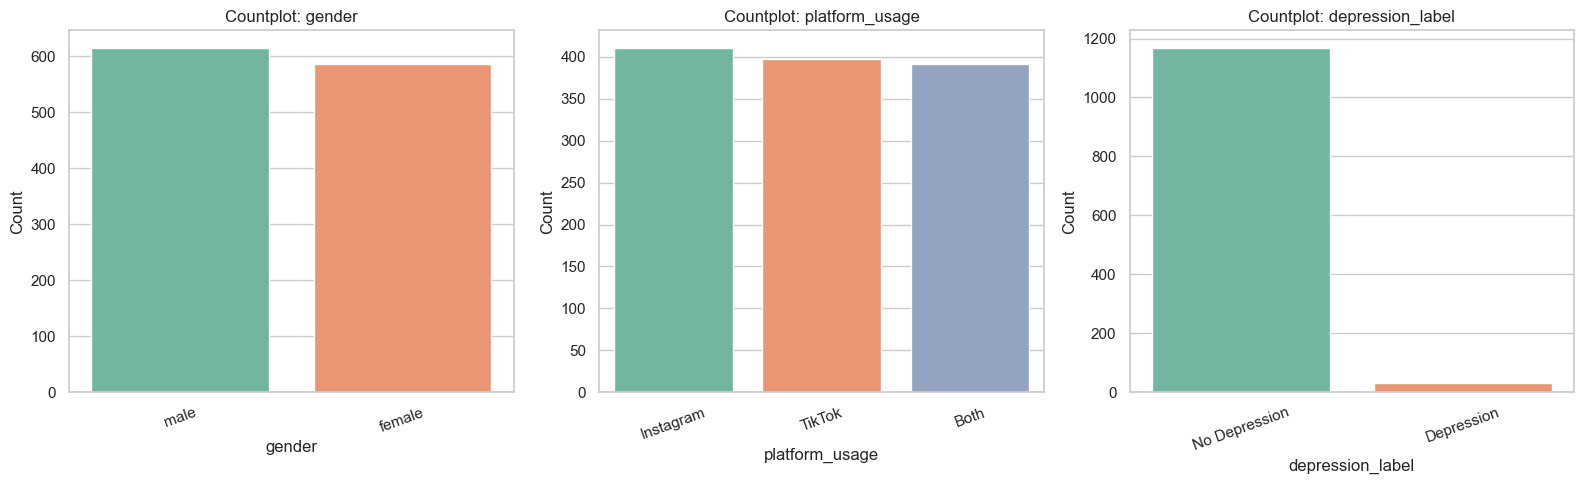

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, ['gender', 'platform_usage', 'depression_label']):
    sns.countplot(data=df, x=col, ax=ax, hue=col, legend=False, palette='Set2')
    ax.set_title(f'Countplot: {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

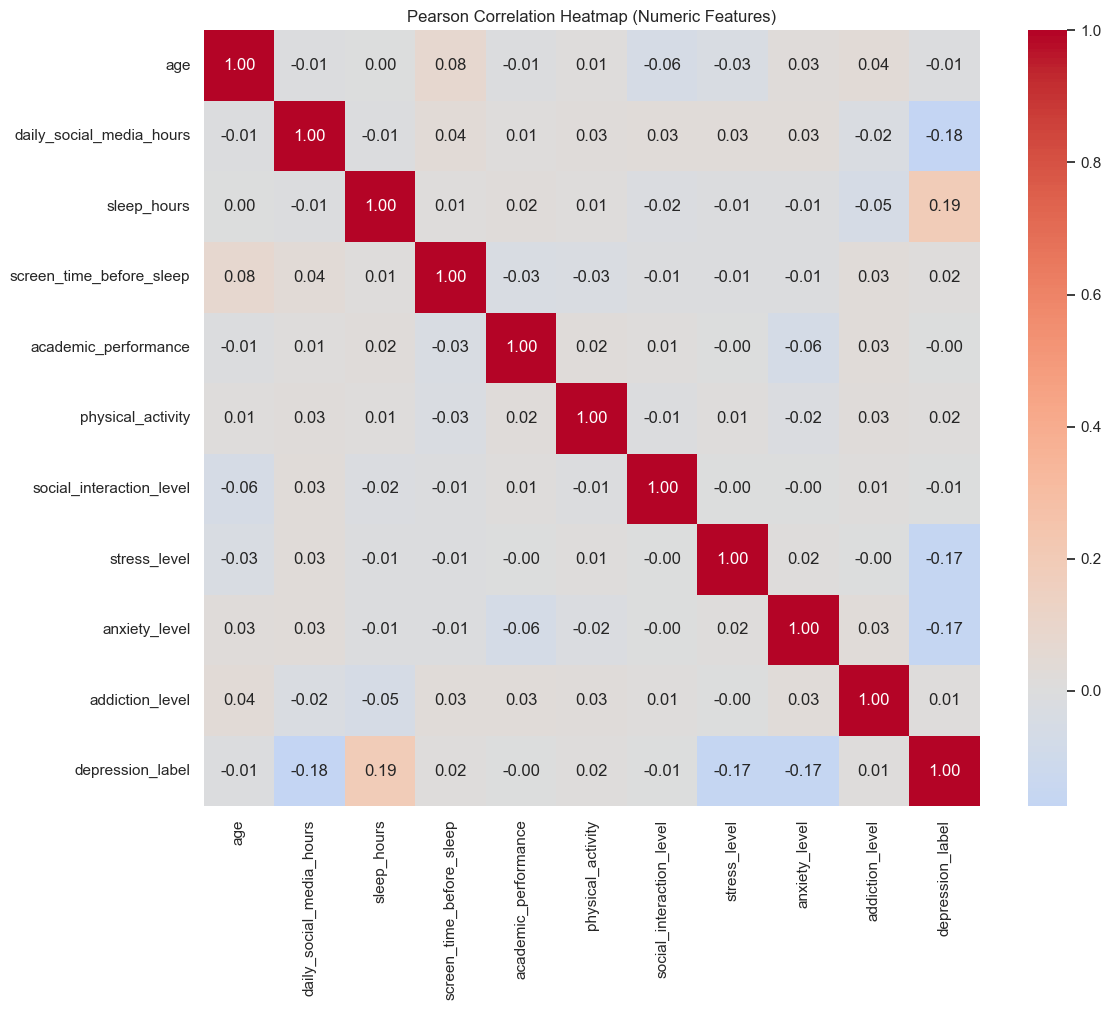

In [9]:
corr_cols = [numeric_col(c) for c in NUMERIC_COLS] + ['depression_label_encoded']
corr = df[corr_cols].corr(method='pearson')
corr.index = NUMERIC_COLS + ['depression_label']
corr.columns = NUMERIC_COLS + ['depression_label']
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Pearson Correlation Heatmap (Numeric Features)')
plt.tight_layout()
plt.show()

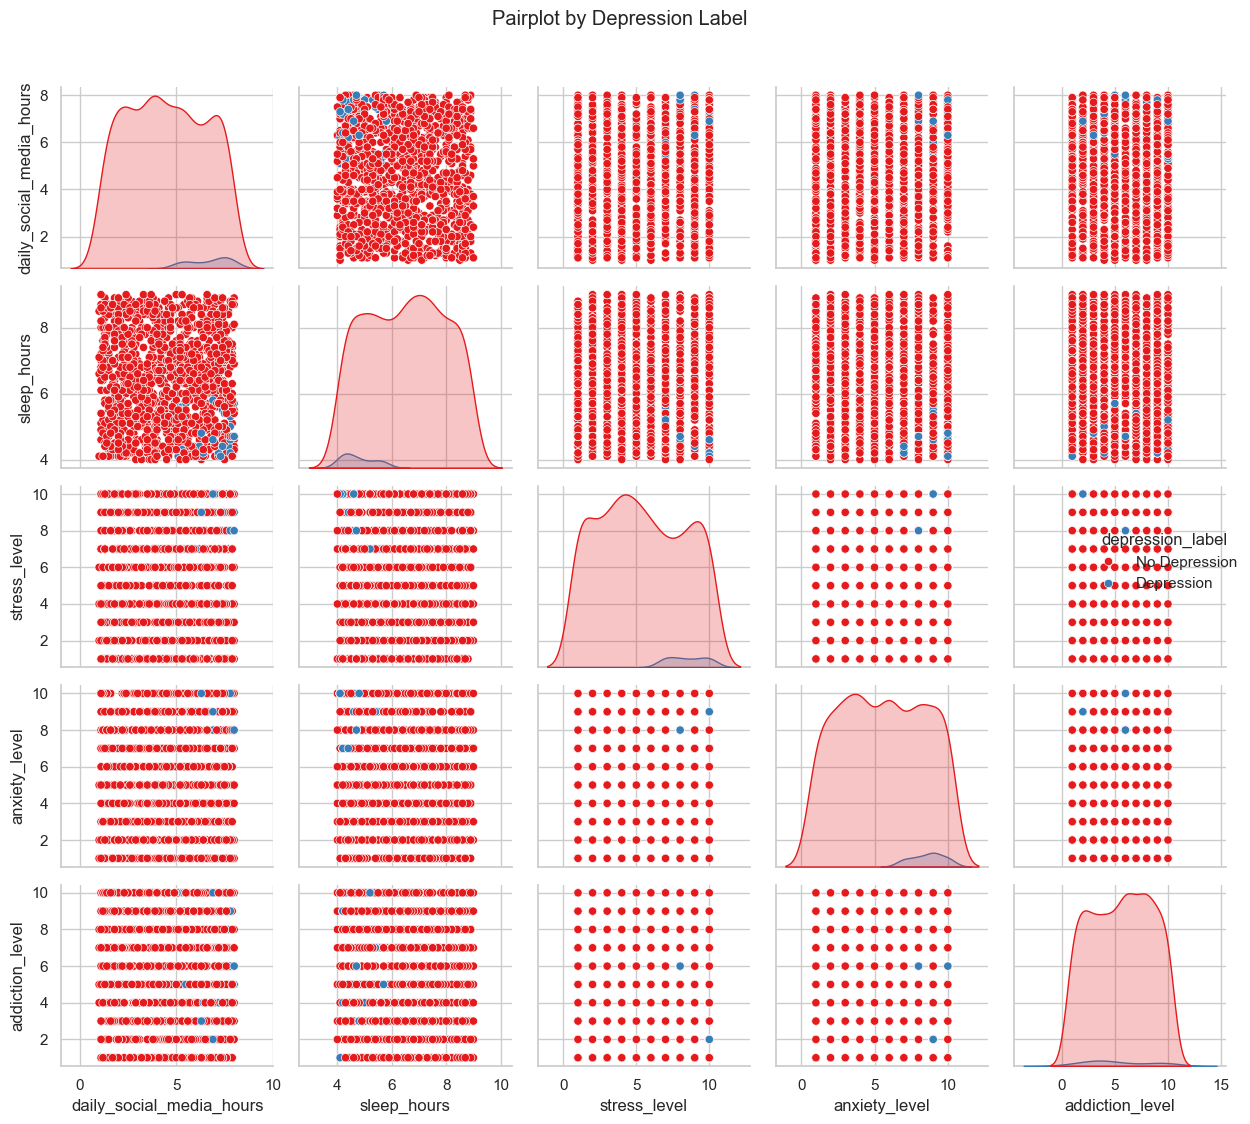

In [10]:
pair_cols = ['daily_social_media_hours', 'sleep_hours', 'stress_level', 'anxiety_level', 'addiction_level']
sns.pairplot(df, vars=pair_cols, hue='depression_label', palette='Set1', diag_kind='kde', height=2.2)
plt.suptitle('Pairplot by Depression Label', y=1.02)
plt.tight_layout()
plt.show()

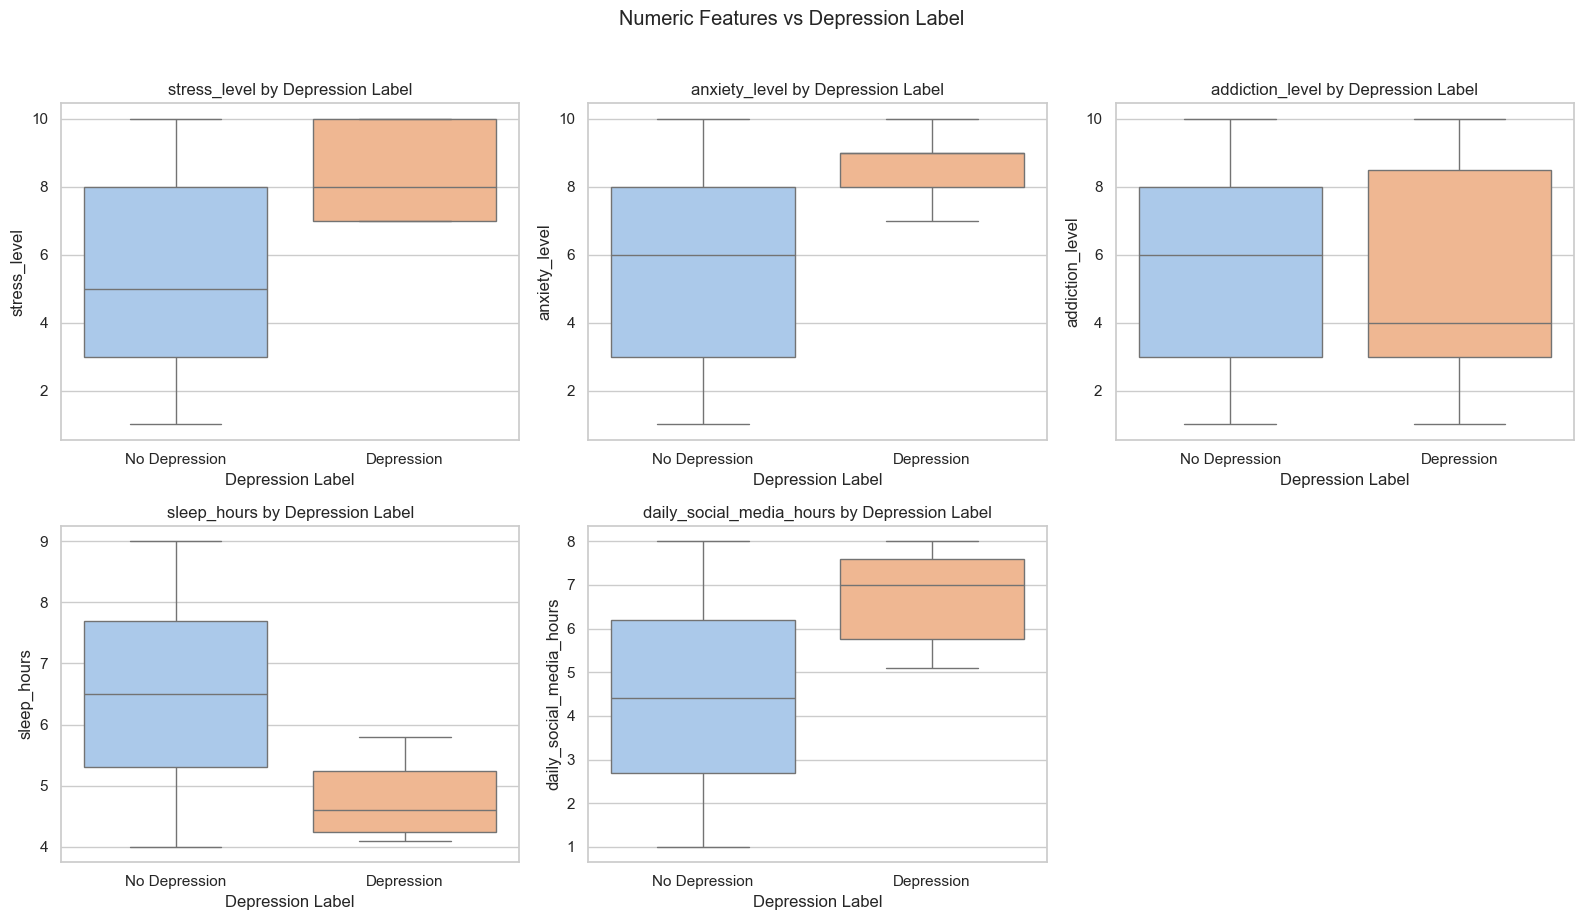

In [11]:
box_cols = ['stress_level', 'anxiety_level', 'addiction_level', 'sleep_hours', 'daily_social_media_hours']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()
for ax, col in zip(axes, box_cols):
    sns.boxplot(data=df, x='depression_label', y=col, ax=ax, palette='pastel')
    ax.set_title(f'{col} by Depression Label')
    ax.set_xlabel('Depression Label')
    ax.set_ylabel(col)
axes[-1].axis('off')
plt.suptitle('Numeric Features vs Depression Label', y=1.02)
plt.tight_layout()
plt.show()

## Section 3 — Deep Statistical Analysis

Hypothesis tests and rank correlations with the encoded target.

IQR outlier counts: {'age': np.int64(0), 'daily_social_media_hours': np.int64(0), 'sleep_hours': np.int64(0), 'screen_time_before_sleep': np.int64(0), 'academic_performance': np.int64(0), 'physical_activity': np.int64(0), 'social_interaction_level': np.int64(0), 'stress_level': np.int64(0), 'anxiety_level': np.int64(0), 'addiction_level': np.int64(0)}


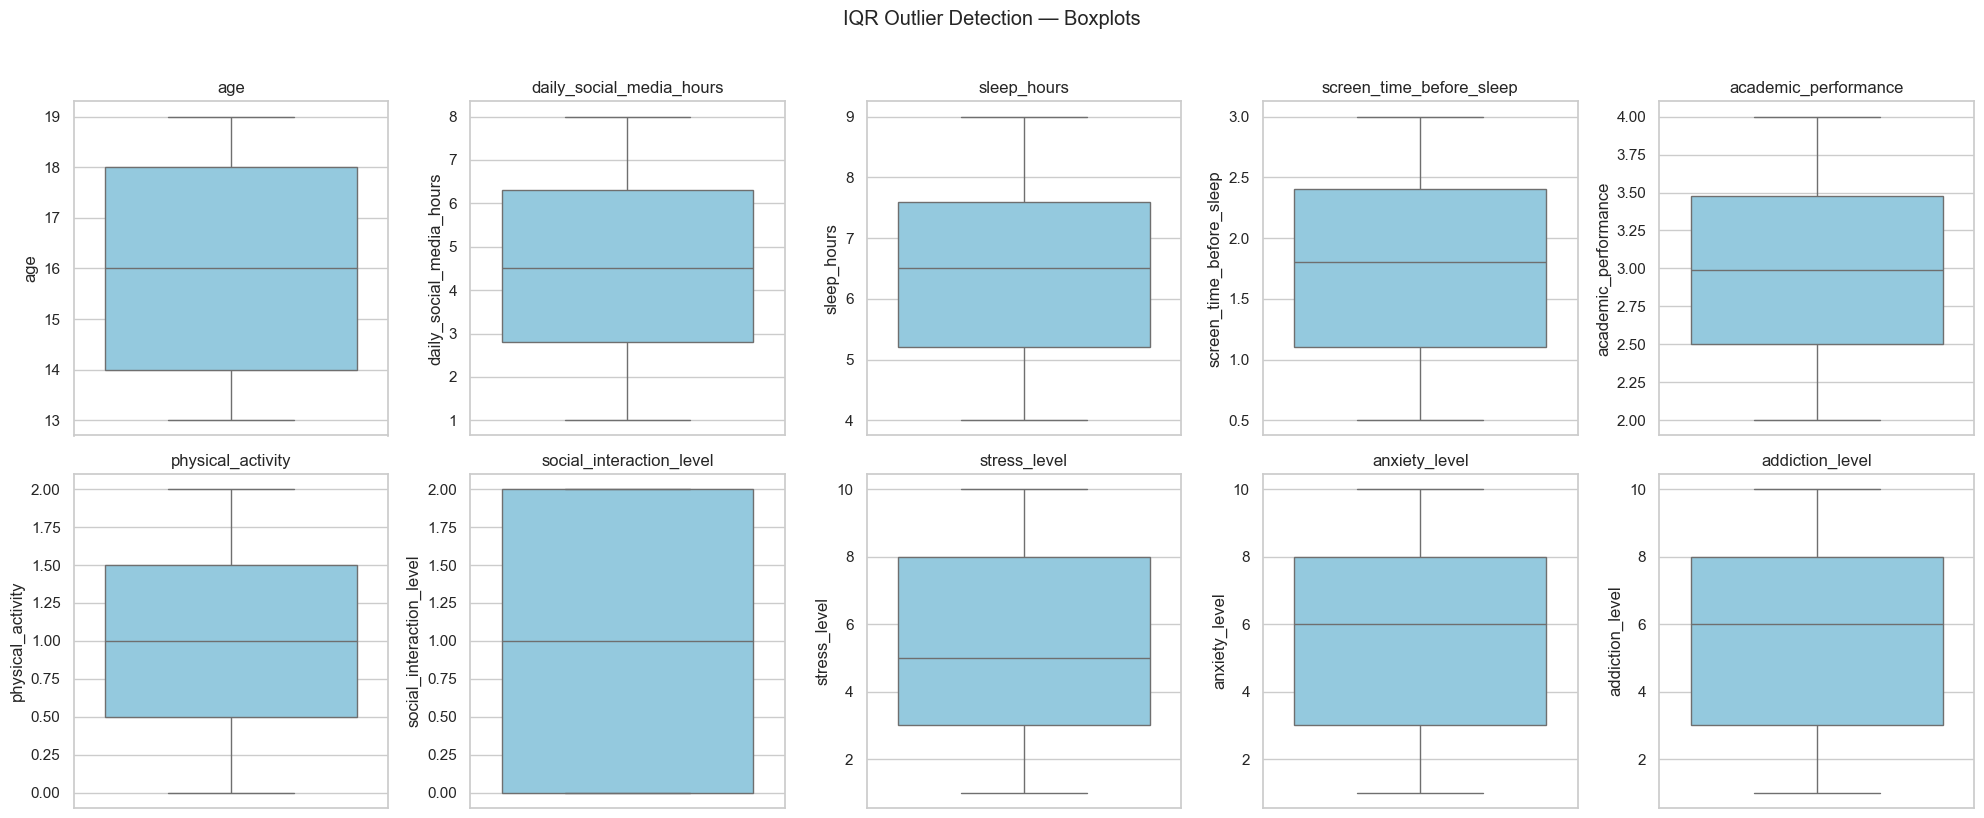

In [12]:
def iqr_outliers(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < low) | (series > high)).sum()

outlier_counts = {c: iqr_outliers(df[numeric_col(c)]) for c in NUMERIC_COLS}
print('IQR outlier counts:', outlier_counts)

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.ravel()
for ax, col in zip(axes, NUMERIC_COLS):
    sns.boxplot(y=df[numeric_col(col)], ax=ax, color='skyblue')
    ax.set_title(col)
    ax.set_ylabel(col)
plt.suptitle('IQR Outlier Detection — Boxplots', y=1.02)
plt.tight_layout()
plt.show()

In [13]:
dep = df['depression_label']
group0 = df.loc[dep == 'No Depression', 'daily_social_media_hours']
group1 = df.loc[dep == 'Depression', 'daily_social_media_hours']
t_stat, p_val = stats.ttest_ind(group0, group1, equal_var=False)
print('Variable: daily_social_media_hours')
print(f't-statistic: {t_stat:.4f}')
print(f'p-value: {p_val:.4e}')
print('Mean (No Depression):', group0.mean())
print('Mean (Depression):', group1.mean())

Variable: daily_social_media_hours
t-statistic: -11.7099
p-value: 6.0635e-14
Mean (No Depression): 4.478785286569718
Mean (Depression): 6.719354838709679


**Interpretation (Social media hours):** If p < 0.05, average `daily_social_media_hours` differs significantly between depressed and non-depressed teens; compare the printed group means to see direction of the effect.

In [14]:
dep = df['depression_label']
group0 = df.loc[dep == 'No Depression', 'sleep_hours']
group1 = df.loc[dep == 'Depression', 'sleep_hours']
t_stat, p_val = stats.ttest_ind(group0, group1, equal_var=False)
print('Variable: sleep_hours')
print(f't-statistic: {t_stat:.4f}')
print(f'p-value: {p_val:.4e}')
print('Mean (No Depression):', group0.mean())
print('Mean (Depression):', group1.mean())

Variable: sleep_hours
t-statistic: 15.7452
p-value: 5.5342e-19
Mean (No Depression): 6.494183062446536
Mean (Depression): 4.761290322580645


**Interpretation (Sleep hours):** If p < 0.05, average `sleep_hours` differs significantly between depressed and non-depressed teens; compare the printed group means to see direction of the effect.

In [15]:
dep = df['depression_label']
group0 = df.loc[dep == 'No Depression', 'anxiety_level']
group1 = df.loc[dep == 'Depression', 'anxiety_level']
t_stat, p_val = stats.ttest_ind(group0, group1, equal_var=False)
print('Variable: anxiety_level')
print(f't-statistic: {t_stat:.4f}')
print(f'p-value: {p_val:.4e}')
print('Mean (No Depression):', group0.mean())
print('Mean (Depression):', group1.mean())

Variable: anxiety_level
t-statistic: -14.7652
p-value: 2.2057e-18
Mean (No Depression): 5.557741659538067
Mean (Depression): 8.612903225806452


**Interpretation (Anxiety level):** If p < 0.05, average `anxiety_level` differs significantly between depressed and non-depressed teens; compare the printed group means to see direction of the effect.

In [16]:
dep = df['depression_label']
group0 = df.loc[dep == 'No Depression', 'addiction_level']
group1 = df.loc[dep == 'Depression', 'addiction_level']
t_stat, p_val = stats.ttest_ind(group0, group1, equal_var=False)
print('Variable: addiction_level')
print(f't-statistic: {t_stat:.4f}')
print(f'p-value: {p_val:.4e}')
print('Mean (No Depression):', group0.mean())
print('Mean (Depression):', group1.mean())

Variable: addiction_level
t-statistic: 0.4526
p-value: 6.5394e-01
Mean (No Depression): 5.571428571428571
Mean (Depression): 5.32258064516129


**Interpretation (Addiction level):** If p < 0.05, average `addiction_level` differs significantly between depressed and non-depressed teens; compare the printed group means to see direction of the effect.

In [17]:
groups = [df.loc[df['platform_usage'] == p, 'stress_level'] for p in df['platform_usage'].unique()]
f_stat, p_val = stats.f_oneway(*groups)
print('ANOVA: stress_level across platform_usage')
print(f'F-statistic: {f_stat:.4f}')
print(f'p-value: {p_val:.4e}')

ANOVA: stress_level across platform_usage
F-statistic: 0.9004
p-value: 4.0670e-01


**Interpretation (ANOVA — stress by platform):** A significant p-value means mean stress_level differs across at least one pair of platform_usage groups (Instagram, TikTok, Both).

In [18]:
groups = [df.loc[df['platform_usage'] == p, 'anxiety_level'] for p in df['platform_usage'].unique()]
f_stat, p_val = stats.f_oneway(*groups)
print('ANOVA: anxiety_level across platform_usage')
print(f'F-statistic: {f_stat:.4f}')
print(f'p-value: {p_val:.4e}')

ANOVA: anxiety_level across platform_usage
F-statistic: 0.8569
p-value: 4.2473e-01


**Interpretation (ANOVA — anxiety by platform):** Significant results imply platform choice is associated with different average anxiety levels.

In [19]:
ct = pd.crosstab(df['gender'], df['depression_label'])
chi2, p_val, dof, expected = stats.chi2_contingency(ct)
print('Chi-square: gender vs depression_label')
print(ct)
print(f'chi2: {chi2:.4f}, p-value: {p_val:.4e}, dof: {dof}')

Chi-square: gender vs depression_label
depression_label  Depression  No Depression
gender                                     
female                    17            568
male                      14            601
chi2: 0.2552, p-value: 6.1347e-01, dof: 1


**Interpretation (Chi-square):** If p < 0.05, depression_label distribution is not independent of gender.

In [20]:
spearman_cols = [
    'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep',
    'stress_level', 'anxiety_level', 'addiction_level', 'academic_performance'
]
spearman_results = []
for col in spearman_cols:
    rho, p = stats.spearmanr(df['depression_label_encoded'], df[col])
    spearman_results.append({'feature': col, 'spearman_rho': rho, 'p_value': p})
spearman_df = pd.DataFrame(spearman_results).sort_values('spearman_rho', key=abs, ascending=False)
display(spearman_df)

,feature,spearman_rho,p_value
1,sleep_hours,0.191006,2.535903e-11
0,daily_social_media_hours,-0.175161,1.004412e-09
4,anxiety_level,-0.169825,3.222940e-09
3,stress_level,-0.169394,3.535622e-09
2,screen_time_before_sleep,0.016383,5.707293e-01
5,addiction_level,0.014022,6.274903e-01
6,academic_performance,-0.001350,9.627489e-01


## Section 4 — Feature Engineering

Create derived features and prepare the modeling matrix.

In [21]:
df['sleep_deficit'] = 8 - df['sleep_hours']
df['screen_load'] = df['daily_social_media_hours'] + df['screen_time_before_sleep']

scaler_mm = MinMaxScaler()
mh = df[['stress_level', 'anxiety_level', 'addiction_level']]
df['mental_health_score'] = scaler_mm.fit_transform(mh).sum(axis=1)

df['usage_category'] = pd.cut(
    df['daily_social_media_hours'],
    bins=[-np.inf, 2, 4, np.inf],
    labels=['Light', 'Moderate', 'Heavy']
)
df['age_group'] = pd.cut(
    df['age'],
    bins=[12, 15, 17, 19],
    labels=['Early Teen (13-15)', 'Mid Teen (16-17)', 'Late Teen (18-19)']
)
display(df[['sleep_deficit', 'screen_load', 'mental_health_score', 'usage_category', 'age_group']].head())

,sleep_deficit,screen_load,mental_health_score,usage_category,age_group
0,0.6,10.8,0.222222,Heavy,Early Teen (13-15)
1,0.0,4.8,1.777778,Light,Late Teen (18-19)
2,0.4,1.8,0.555556,Light,Mid Teen (16-17)
3,1.1,9.0,1.555556,Heavy,Early Teen (13-15)
4,3.1,7.7,0.777778,Heavy,Early Teen (13-15)


In [22]:
df_model = df.copy()
ohe_cols = ['gender', 'platform_usage', 'usage_category', 'age_group']
df_model = pd.get_dummies(df_model, columns=ohe_cols, drop_first=True)

feature_exclude = {'depression_label', 'depression_label_encoded', 'social_interaction_level'}
numeric_features = [
    'age', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep',
    'academic_performance', 'physical_activity', 'stress_level', 'anxiety_level',
    'addiction_level', 'sleep_deficit', 'screen_load', 'mental_health_score',
    'gender_encoded', 'platform_usage_encoded', 'social_interaction_level_encoded'
]
ohe_feature_cols = [c for c in df_model.columns if c not in feature_exclude and c not in numeric_features]
X_cols = [c for c in numeric_features + ohe_feature_cols if c in df_model.columns]

scaler = StandardScaler()
df_model[X_cols] = scaler.fit_transform(df_model[X_cols])
print('Final feature matrix shape (rows, features):', df_model[X_cols].shape)

Final feature matrix shape (rows, features): (1200, 22)


## Section 5 — Advanced Visualizations

Interactive and multivariate views of relationships.

In [23]:
fig = px.scatter(
    df, x='daily_social_media_hours', y='anxiety_level', color='depression_label',
    size='addiction_level', hover_data=['platform_usage', 'sleep_hours'],
    title='Social Media Hours vs Anxiety (by Depression Label)',
    labels={'daily_social_media_hours': 'Daily Social Media (h)', 'anxiety_level': 'Anxiety Level'}
)
fig.update_layout(legend_title_text='Depression Label')
fig.show()

In [24]:
melted = df.melt(id_vars='platform_usage', value_vars=['stress_level', 'anxiety_level'],
                 var_name='metric', value_name='score')
fig = px.box(melted, x='platform_usage', y='score', color='metric',
             title='Stress & Anxiety by Platform Usage')
fig.update_layout(xaxis_title='Platform', yaxis_title='Score', legend_title='Metric')
fig.show()

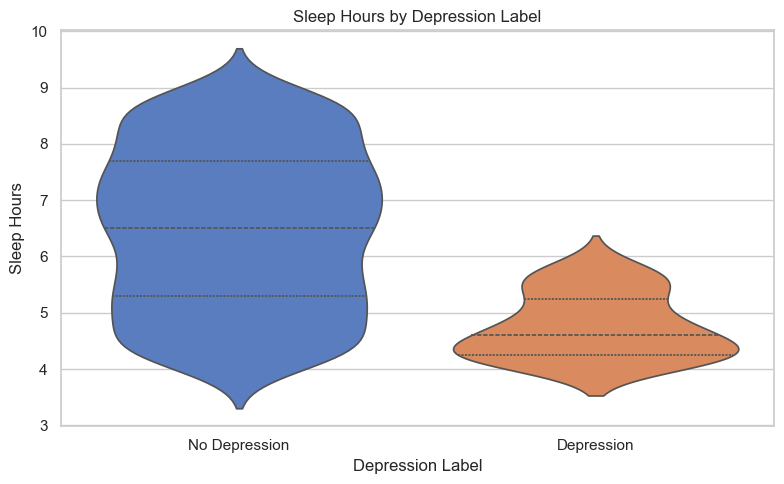

In [25]:
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x='depression_label', y='sleep_hours', palette='muted', inner='quartile')
plt.title('Sleep Hours by Depression Label')
plt.xlabel('Depression Label')
plt.ylabel('Sleep Hours')
plt.legend([], [], frameon=False)
plt.tight_layout()
plt.show()

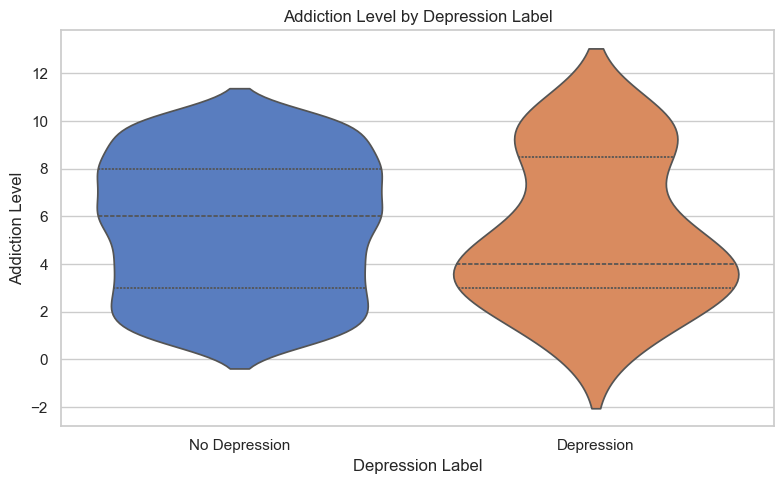

In [26]:
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x='depression_label', y='addiction_level', palette='muted', inner='quartile')
plt.title('Addiction Level by Depression Label')
plt.xlabel('Depression Label')
plt.ylabel('Addiction Level')
plt.tight_layout()
plt.show()

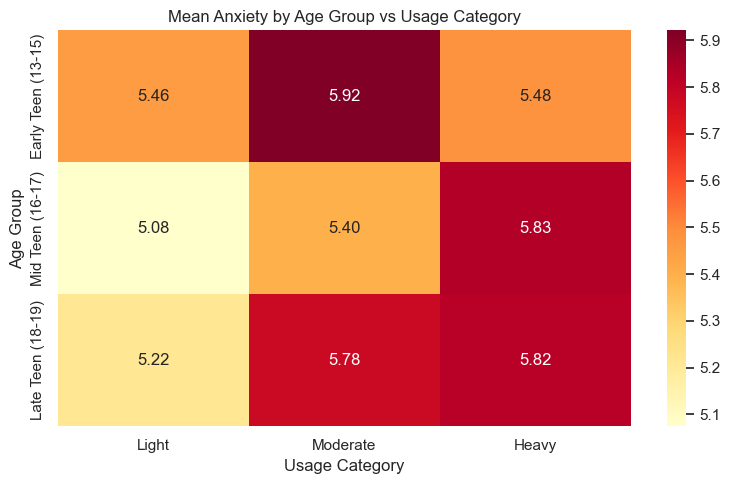

In [27]:
pivot_anx = df.pivot_table(values='anxiety_level', index='age_group', columns='usage_category', aggfunc='mean')
plt.figure(figsize=(8, 5))
sns.heatmap(pivot_anx, annot=True, fmt='.2f', cmap='YlOrRd')
plt.title('Mean Anxiety by Age Group vs Usage Category')
plt.xlabel('Usage Category')
plt.ylabel('Age Group')
plt.tight_layout()
plt.show()

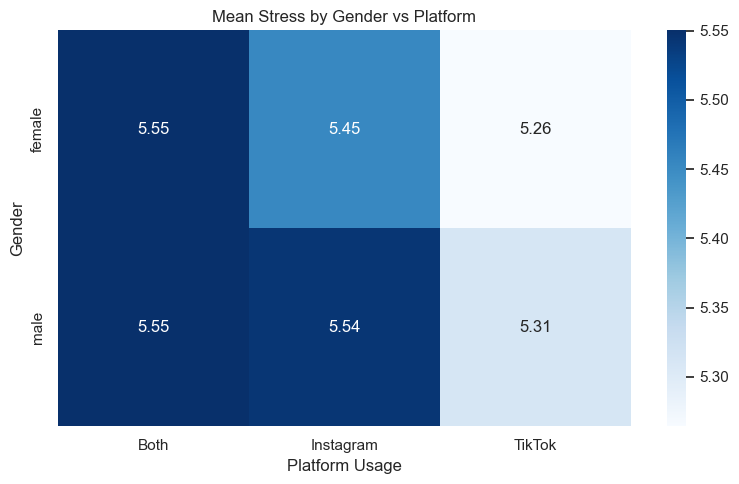

In [28]:
pivot_stress = df.pivot_table(values='stress_level', index='gender', columns='platform_usage', aggfunc='mean')
plt.figure(figsize=(8, 5))
sns.heatmap(pivot_stress, annot=True, fmt='.2f', cmap='Blues')
plt.title('Mean Stress by Gender vs Platform')
plt.xlabel('Platform Usage')
plt.ylabel('Gender')
plt.tight_layout()
plt.show()

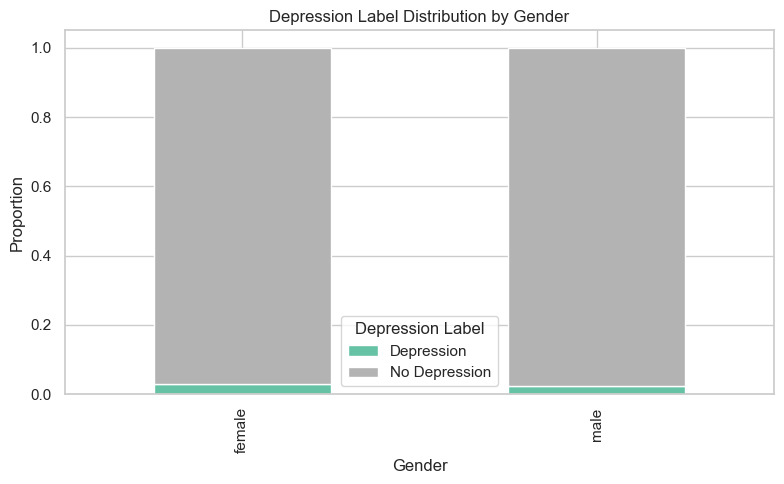

In [29]:
ct_gender = pd.crosstab(df['gender'], df['depression_label'], normalize='index')
ct_gender.plot(kind='bar', stacked=True, figsize=(8, 5), colormap='Set2')
plt.title('Depression Label Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Proportion')
plt.legend(title='Depression Label')
plt.tight_layout()
plt.show()

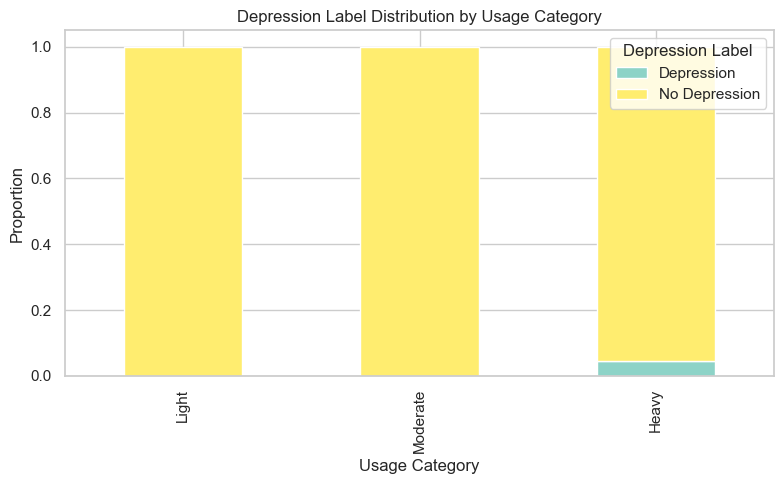

In [30]:
ct_usage = pd.crosstab(df['usage_category'], df['depression_label'], normalize='index')
ct_usage.plot(kind='bar', stacked=True, figsize=(8, 5), colormap='Set3')
plt.title('Depression Label Distribution by Usage Category')
plt.xlabel('Usage Category')
plt.ylabel('Proportion')
plt.legend(title='Depression Label')
plt.tight_layout()
plt.show()

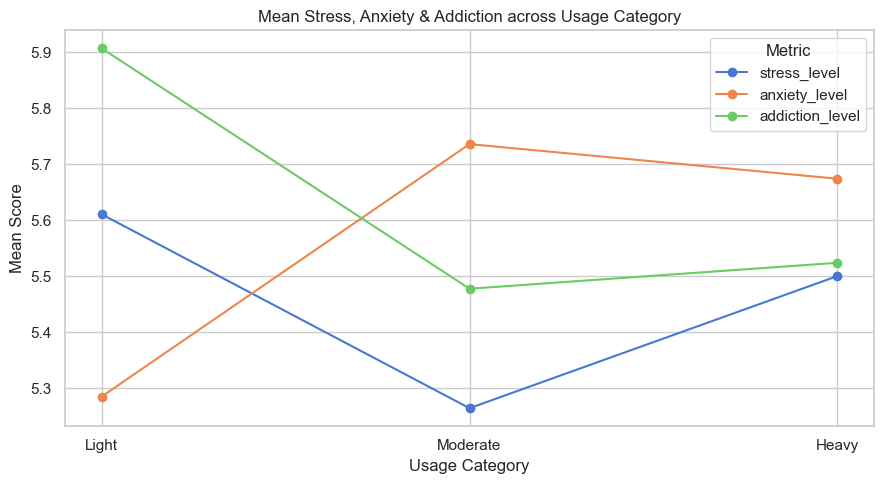

In [31]:
line_df = df.groupby('usage_category')[['stress_level', 'anxiety_level', 'addiction_level']].mean().reset_index()
plt.figure(figsize=(9, 5))
for col in ['stress_level', 'anxiety_level', 'addiction_level']:
    plt.plot(line_df['usage_category'].astype(str), line_df[col], marker='o', label=col)
plt.title('Mean Stress, Anxiety & Addiction across Usage Category')
plt.xlabel('Usage Category')
plt.ylabel('Mean Score')
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

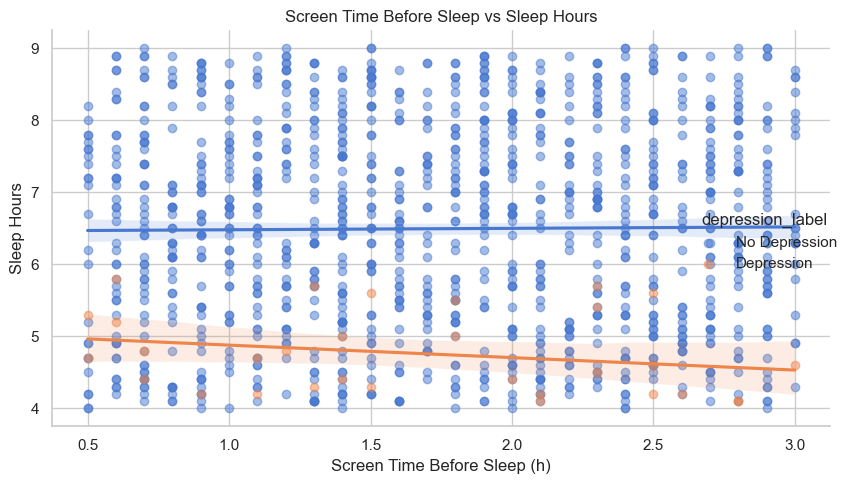

In [32]:
plt.figure(figsize=(8, 5))
sns.lmplot(data=df, x='screen_time_before_sleep', y='sleep_hours', hue='depression_label',
           height=5, aspect=1.4, scatter_kws={'alpha': 0.5})
plt.title('Screen Time Before Sleep vs Sleep Hours')
plt.xlabel('Screen Time Before Sleep (h)')
plt.ylabel('Sleep Hours')
plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

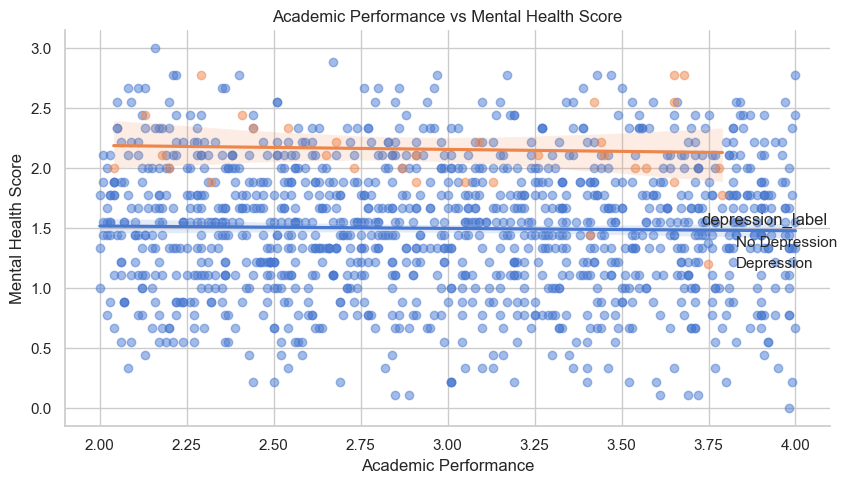

In [33]:
plt.figure(figsize=(8, 5))
sns.lmplot(data=df, x='academic_performance', y='mental_health_score', hue='depression_label',
           height=5, aspect=1.4, scatter_kws={'alpha': 0.5})
plt.title('Academic Performance vs Mental Health Score')
plt.xlabel('Academic Performance')
plt.ylabel('Mental Health Score')
plt.tight_layout()
plt.show()

## Section 6 — Machine Learning

Train four classifiers and compare performance on the encoded target.

In [34]:
X = df_model[X_cols]
y = df_model['depression_label_encoded']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print('Train shape:', X_train.shape, '| Test shape:', X_test.shape)

Train shape: (960, 22) | Test shape: (240, 22)


Logistic Regression
               precision    recall  f1-score   support

   Depression       1.00      0.33      0.50         6
No Depression       0.98      1.00      0.99       234

     accuracy                           0.98       240
    macro avg       0.99      0.67      0.75       240
 weighted avg       0.98      0.98      0.98       240



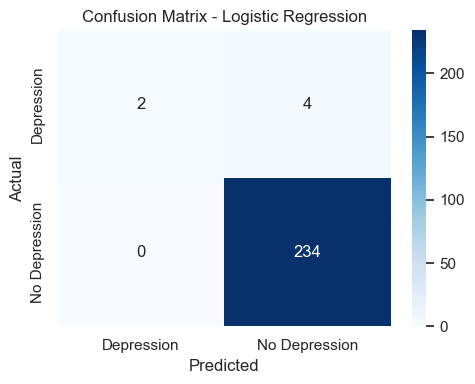

5-fold CV accuracy: 0.9800 +/- 0.0072


ROC-AUC (OvR, macro): 0.9936


Random Forest
               precision    recall  f1-score   support

   Depression       1.00      0.17      0.29         6
No Depression       0.98      1.00      0.99       234

     accuracy                           0.98       240
    macro avg       0.99      0.58      0.64       240
 weighted avg       0.98      0.98      0.97       240



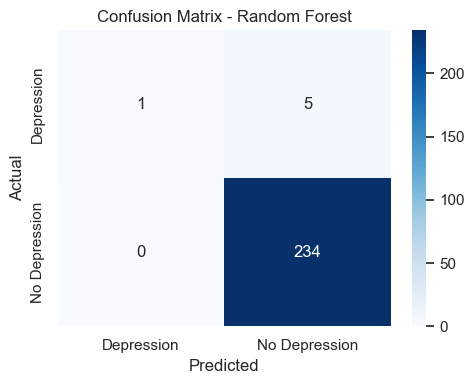

5-fold CV accuracy: 0.9800 +/- 0.0017
ROC-AUC (OvR, macro): 1.0000
XGBoost
               precision    recall  f1-score   support

   Depression       1.00      0.67      0.80         6
No Depression       0.99      1.00      1.00       234

     accuracy                           0.99       240
    macro avg       1.00      0.83      0.90       240
 weighted avg       0.99      0.99      0.99       240



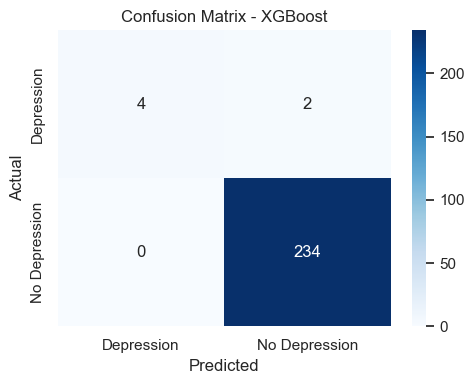

5-fold CV accuracy: 0.9958 +/- 0.0037
ROC-AUC (OvR, macro): 1.0000
SVM (RBF)
               precision    recall  f1-score   support

   Depression       0.00      0.00      0.00         6
No Depression       0.97      1.00      0.99       234

     accuracy                           0.97       240
    macro avg       0.49      0.50      0.49       240
 weighted avg       0.95      0.97      0.96       240



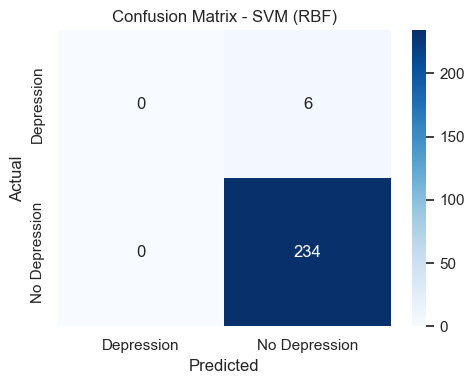

5-fold CV accuracy: 0.9742 +/- 0.0017
ROC-AUC (OvR, macro): 0.9922


,Model,CV Accuracy,Test Accuracy,F1-Macro,ROC-AUC
2,XGBoost,0.995833,0.991667,0.897872,1.000000
0,Logistic Regression,0.980000,0.983333,0.745763,0.993590
1,Random Forest,0.980000,0.979167,0.637572,1.000000
3,SVM (RBF),0.974167,0.975000,0.493671,0.992165


In [35]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0),
    'SVM (RBF)': SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE)
}
results = []
fitted = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    fitted[name] = model
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)
    print('=' * 60)
    print(name)
    print(classification_report(y_test, y_pred, target_names=le_dep.classes_))
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le_dep.classes_, yticklabels=le_dep.classes_)
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    print(f'5-fold CV accuracy: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')
    if len(le_dep.classes_) == 2:
        roc = roc_auc_score(y_test, y_proba[:, 1])
    else:
        roc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
    print(f'ROC-AUC (OvR, macro): {roc:.4f}')
    results.append({
        'Model': name,
        'CV Accuracy': cv_scores.mean(),
        'Test Accuracy': accuracy_score(y_test, y_pred),
        'F1-Macro': f1_score(y_test, y_pred, average='macro'),
        'ROC-AUC': roc
    })

comparison = pd.DataFrame(results).sort_values('F1-Macro', ascending=False)
display(comparison)

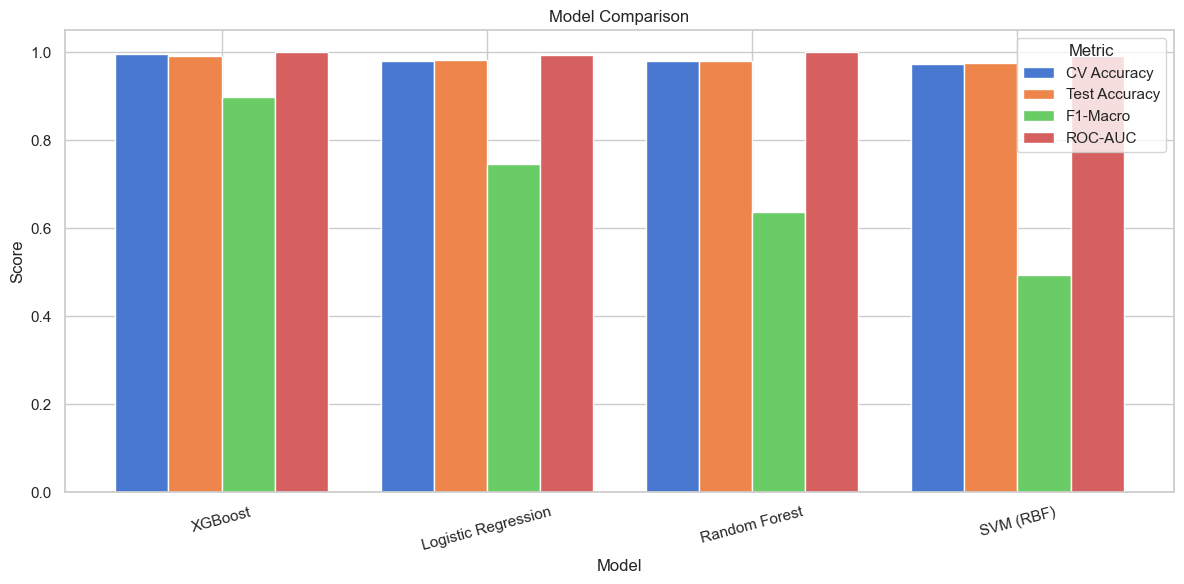

In [36]:
metrics = ['CV Accuracy', 'Test Accuracy', 'F1-Macro', 'ROC-AUC']
x = np.arange(len(comparison))
width = 0.2
plt.figure(figsize=(12, 6))
for i, metric in enumerate(metrics):
    plt.bar(x + i * width, comparison[metric], width, label=metric)
plt.xticks(x + width * 1.5, comparison['Model'], rotation=15)
plt.title('Model Comparison')
plt.xlabel('Model')
plt.ylabel('Score')
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

## Section 7 — Model Explainability (SHAP)

Explain the best tree-based model with SHAP.

In [37]:
best_name = comparison.iloc[0]['Model']
if best_name not in ('Random Forest', 'XGBoost'):
    best_name = 'Random Forest'
best_model = fitted[best_name]
print('SHAP model:', best_name)

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)
if isinstance(shap_values, list):
    shap_vals_plot = shap_values[1] if len(shap_values) > 1 else shap_values[0]
else:
    shap_vals_plot = shap_values

SHAP model: XGBoost


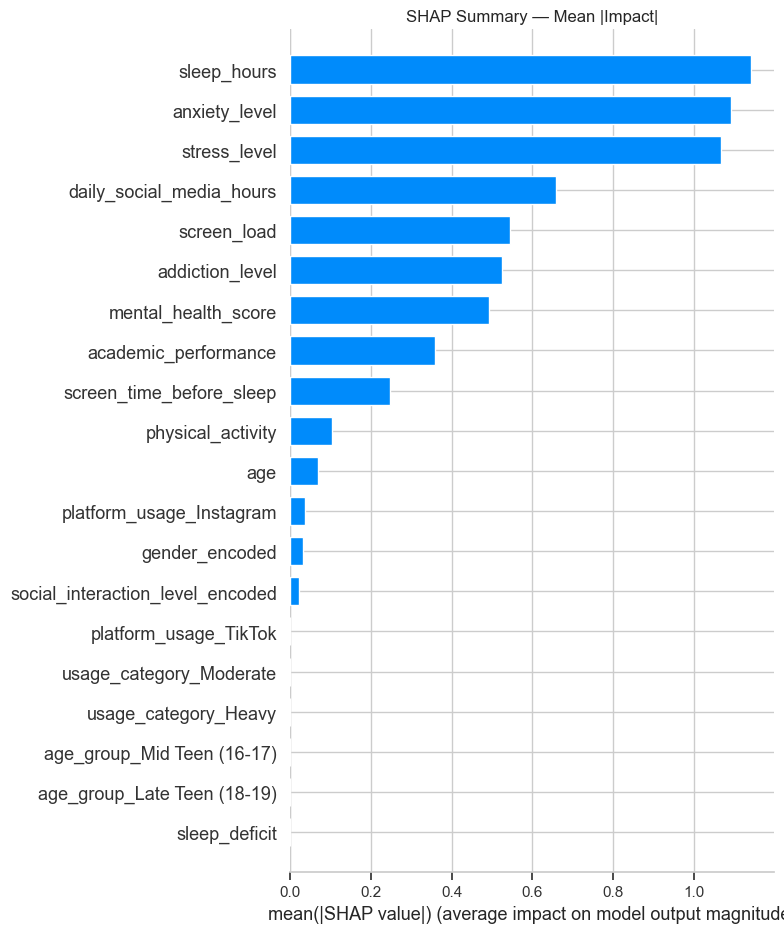

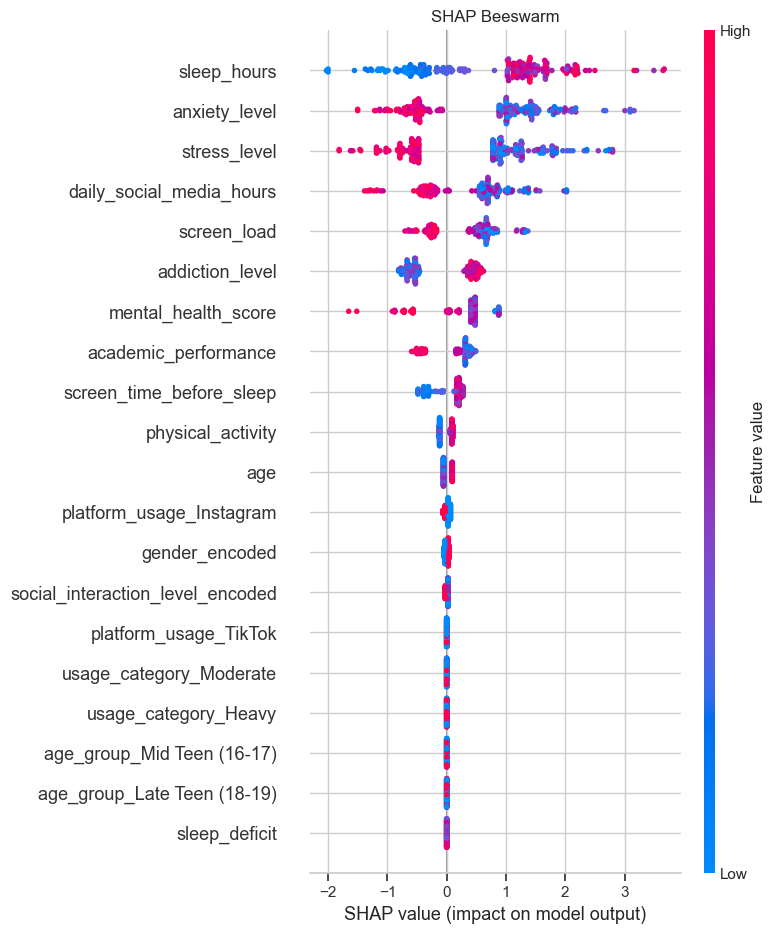

In [38]:
plt.figure()
shap.summary_plot(shap_vals_plot, X_test, plot_type='bar', show=False)
plt.title('SHAP Summary — Mean |Impact|')
plt.tight_layout()
plt.show()

plt.figure()
shap.summary_plot(shap_vals_plot, X_test, show=False)
plt.title('SHAP Beeswarm')
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

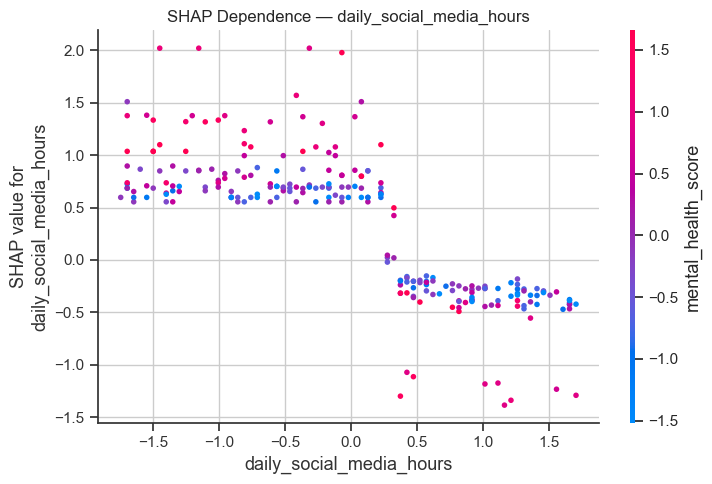

<Figure size 1000x600 with 0 Axes>

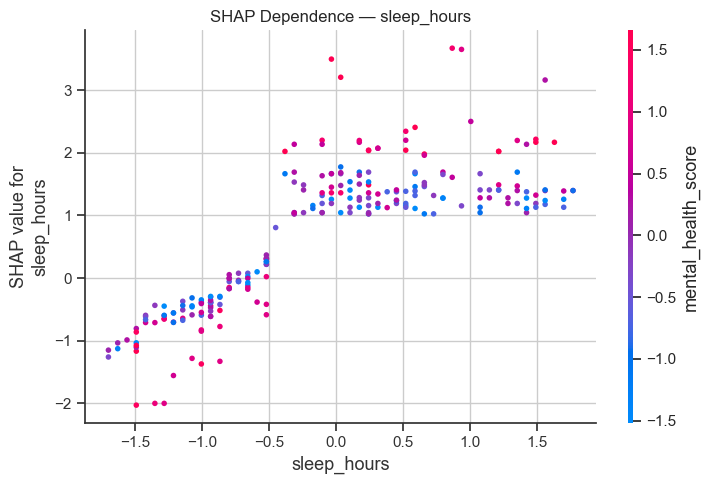

<Figure size 1000x600 with 0 Axes>

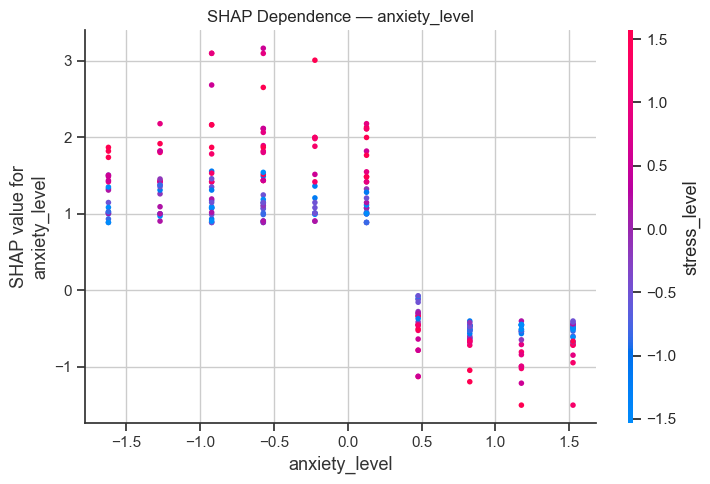

In [39]:
for feat in ['daily_social_media_hours', 'sleep_hours', 'anxiety_level']:
    if feat in X_test.columns:
        plt.figure()
        shap.dependence_plot(feat, shap_vals_plot, X_test, show=False)
        plt.title(f'SHAP Dependence — {feat}')
        plt.tight_layout()
        plt.show()

### SHAP interpretation

- **Bar plot:** Features with the largest mean |SHAP| value drive predictions most strongly.
- **Beeswarm:** Red (high feature value) vs blue (low) shows whether higher values push toward depression.
- **Dependence plots:** Curves for `daily_social_media_hours`, `sleep_hours`, and `anxiety_level` show non-linear thresholds where risk increases.
- Expect **anxiety_level**, **addiction_level**, and **stress_level** (via mental_health_score) to rank high if they separate classes well in EDA.

## Section 8 — Key Insights & Conclusions

### Data-driven findings (13 columns)
1. **Target balance:** Depression prevalence and class balance should be checked from `depression_label` counts in Section 1.
2. **Social media dose:** Mean `daily_social_media_hours` and `usage_category` (Light/Moderate/Heavy) relate to stress/anxiety trajectories in Section 5 line plots.
3. **Sleep pathway:** `sleep_hours` and `screen_time_before_sleep` jointly shape rest; `sleep_deficit` captures sub-8-hour sleep.
4. **Symptom cluster:** `stress_level`, `anxiety_level`, and `addiction_level` form the core mental-health burden (mental_health_score).
5. **Platform effect:** ANOVA on `platform_usage` tests whether Instagram, TikTok, or Both differ in mean stress/anxiety.
6. **Gender association:** Chi-square links `gender` with depression distribution.
7. **Academics & activity:** `academic_performance` and `physical_activity` Spearman correlations show protective or risk associations with encoded depression.
8. **Social interaction:** `social_interaction_level` (low/medium/high) adds social context alongside numeric predictors.

### Recommendations
- **Teens:** Cap heavy (>4h) `daily_social_media_hours`; reduce `screen_time_before_sleep`; prioritize 8+ `sleep_hours`.
- **Parents:** Monitor `addiction_level` and evening screens; encourage `physical_activity` and offline social interaction.
- **Schools:** Screen for high `stress_level`/`anxiety_level`; link counseling to academic support when `academic_performance` drops.
- **Policymakers:** Fund platform-aware education; require age-appropriate design reducing night-time engagement.

### Platform with highest risk
See the computed table in the next cell — platform with highest mean `anxiety_level` and depression rate.

### Best model
The comparison table in Section 6 ranks models by **F1-Macro**; tree ensembles typically win on mixed numeric/categorical features after scaling and one-hot encoding.

### Limitations
- Cross-sectional data — causality cannot be inferred.
- `depression_label` is binary in this file (not Mild/Severe tiers).
- Self-reported hours and scales may include bias.
- Suggested improvements: longitudinal tracking, clinical validation, more platforms, and larger sample.

In [40]:
platform_risk = df.groupby('platform_usage').agg(
    depression_rate=('depression_label', lambda s: (s == 'Depression').mean()),
    mean_anxiety=('anxiety_level', 'mean'),
    mean_stress=('stress_level', 'mean')
).sort_values('depression_rate', ascending=False)
print('Platform risk summary:')
display(platform_risk)
print('\nBest model (by F1-Macro):', comparison.iloc[0]['Model'])
print(comparison.iloc[0].to_string())

Platform risk summary:


,depression_rate,mean_anxiety,mean_stress
platform_usage,,,
TikTok,0.030151,5.748744,5.288945
Instagram,0.024331,5.669100,5.498783
Both,0.023018,5.488491,5.549872



Best model (by F1-Macro): XGBoost
Model             XGBoost
CV Accuracy      0.995833
Test Accuracy    0.991667
F1-Macro         0.897872
ROC-AUC               1.0
